# Linear Model in Python

This notebook fits a simple linear model to salary data, reports slope, intercept, Pearson's *r*, and MSE, and displays an annotated regression plot.

## Step 1: Import libraries

Load pandas for data handling, matplotlib for plotting, scikit-learn for regression, and metrics for MSE.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline

## Step 2: Read and display the data

Load `regression_data.csv` and inspect the first rows.

In [2]:
data = pd.read_csv("regression_data.csv")
data

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.7,57189.0
9,4.0,63218.0


## Step 3: Explore the relationship

A scatter plot shows how salary changes with years of experience before fitting the model.

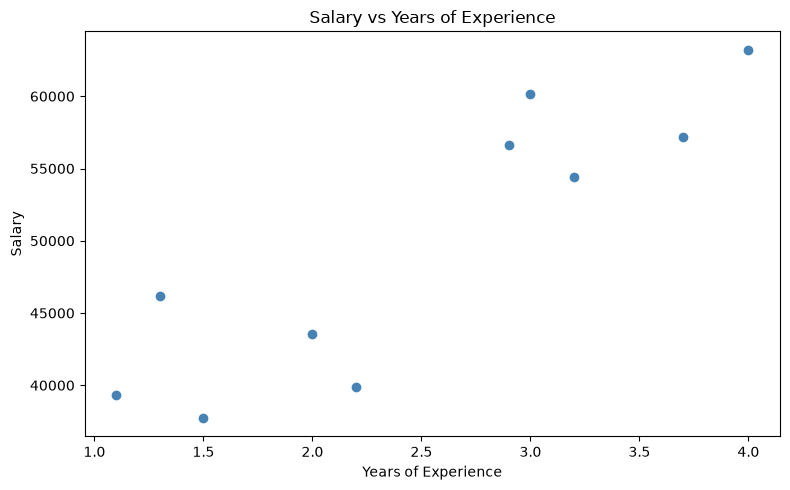

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(data["YearsExperience"], data["Salary"], color="steelblue")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Years of Experience")
plt.tight_layout()
plt.show()

## Step 4: Fit the linear model

Fit `Salary ~ YearsExperience` with scikit-learn and store the slope and intercept from the fitted model.

In [4]:
X = data[["YearsExperience"]]
y = data["Salary"]

model = LinearRegression()
model.fit(X, y)

slope = float(model.coef_[0])
intercept = float(model.intercept_)

## Step 5: Predicted values

Compare each observed salary with the value predicted by the fitted line.

In [5]:
y_pred = model.predict(X)

predictions = pd.DataFrame(
    {
        "YearsExperience": data["YearsExperience"],
        "Observed_Salary": y,
        "Predicted_Salary": y_pred,
        "Residual": y - y_pred,
    }
)
predictions

,YearsExperience,Observed_Salary,Predicted_Salary,Residual
0,1.1,39343.0,38317.343981,1025.656019
1,1.3,46205.0,39974.402401,6230.597599
2,1.5,37731.0,41631.460821,-3900.460821
3,2.0,43525.0,45774.106871,-2249.106871
4,2.2,39891.0,47431.165291,-7540.165291
5,2.9,56642.0,53230.869761,3411.130239
6,3.0,60150.0,54059.398971,6090.601029
7,3.2,54445.0,55716.457391,-1271.457391
8,3.7,57189.0,59859.103441,-2670.103441
9,4.0,63218.0,62344.691071,873.308929


## Step 6: Regression statistics

Print the four required statistics from the fitted model: slope, intercept, Pearson's correlation coefficient (*r*), and MSE. R-squared is included only as an optional extra metric.

In [6]:
pearson_r = float(np.corrcoef(data["YearsExperience"], data["Salary"])[0, 1])
mse = float(mean_squared_error(y, y_pred))
r2 = float(r2_score(y, y_pred))

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Pearson's r: {pearson_r:.6f}")
print(f"MSE: {mse:.4f}")
print(f"R-squared (optional): {r2:.6f}")

Slope: 8285.2921
Intercept: 29203.5227
Pearson's r: 0.886088
MSE: 17523844.0829
R-squared (optional): 0.785152


## Step 7: Annotated regression plot

Overlay the fitted line on the scatter plot and annotate the chart with the regression equation and key metrics.

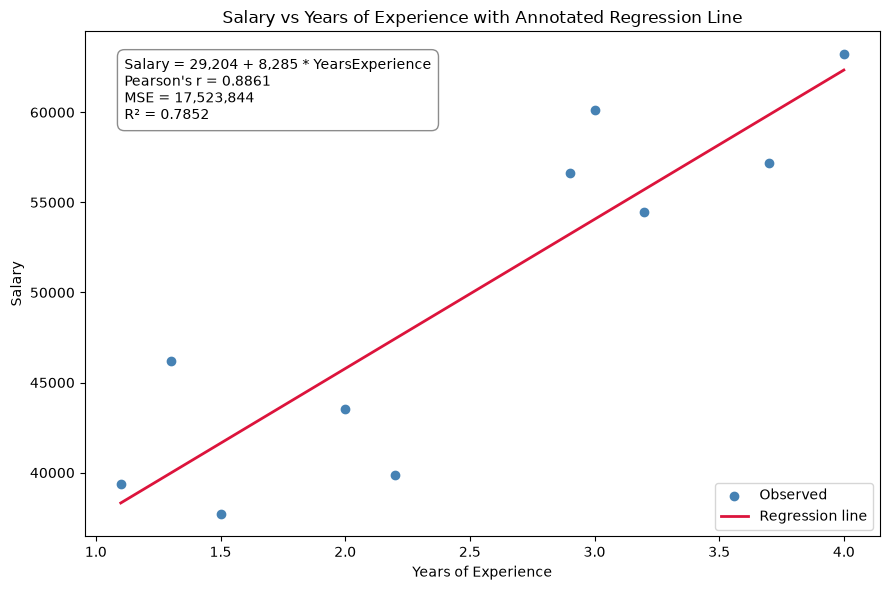

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(data["YearsExperience"], data["Salary"], color="steelblue", label="Observed")

x_line = np.linspace(data["YearsExperience"].min(), data["YearsExperience"].max(), 100)
ax.plot(x_line, intercept + slope * x_line, color="crimson", linewidth=2, label="Regression line")

equation = f"Salary = {intercept:,.0f} + {slope:,.0f} * YearsExperience"
annotation = (
    f"{equation}\n"
    f"Pearson's r = {pearson_r:.4f}\n"
    f"MSE = {mse:,.0f}\n"
    f"R² = {r2:.4f}"
)
ax.text(
    0.05,
    0.95,
    annotation,
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
    fontsize=10,
)

ax.set_xlabel("Years of Experience")
ax.set_ylabel("Salary")
ax.set_title("Salary vs Years of Experience with Annotated Regression Line")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()